In [46]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

### Right-skewed data generation

In [47]:
np.random.seed(42)

# Generate right-skewed data using an exponential distribution
poids = np.random.exponential(scale=700, size=300) + 1600

# Create the DataFrame
df = pd.DataFrame({"poids": poids})

### Z-score Standardization

In [48]:
scaler = StandardScaler()

# Fit and transform the 'poids' column, then save it to 'weight_z'
df["weight_z"] = scaler.fit_transform(df[["poids"]])

### Histogram of original data

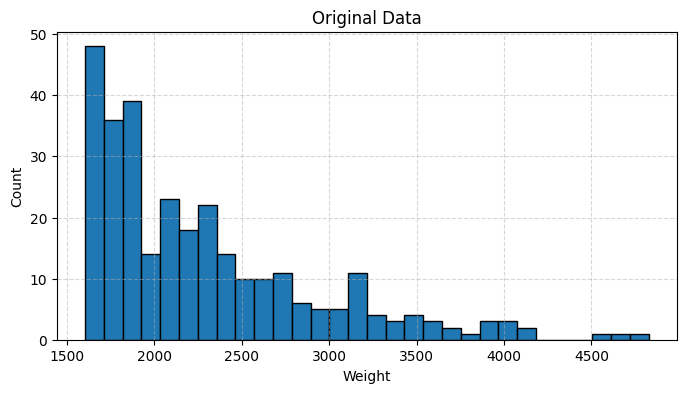

In [49]:
plt.figure(figsize=(8, 4))

plt.hist(
    df["poids"],
    bins=30,
    edgecolor="black"
)

plt.title("Original Data")
plt.xlabel("Weight")
plt.ylabel("Count")

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Histogram of standardized data

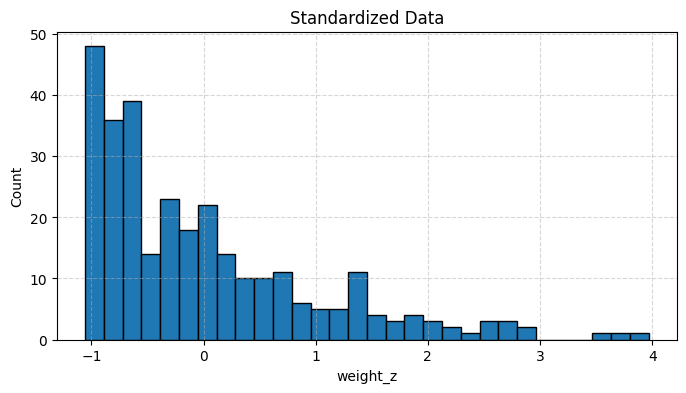

In [50]:
plt.figure(figsize=(8, 4))

plt.hist(
    df["weight_z"],
    bins=30,
    edgecolor="black"
)

plt.title("Standardized Data")
plt.xlabel("weight_z")
plt.ylabel("Count")

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Normal distribution curve

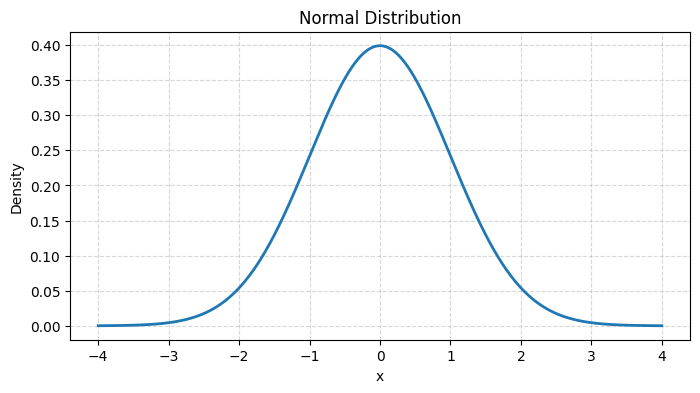

In [51]:
x = np.linspace(-4, 4, 1000)

y = norm.pdf(x, loc=0, scale=1)

plt.figure(figsize=(8, 4))

plt.plot(x, y, linewidth=2)

plt.title("Normal Distribution")
plt.xlabel("x")
plt.ylabel("Density")

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Normal distribution curve

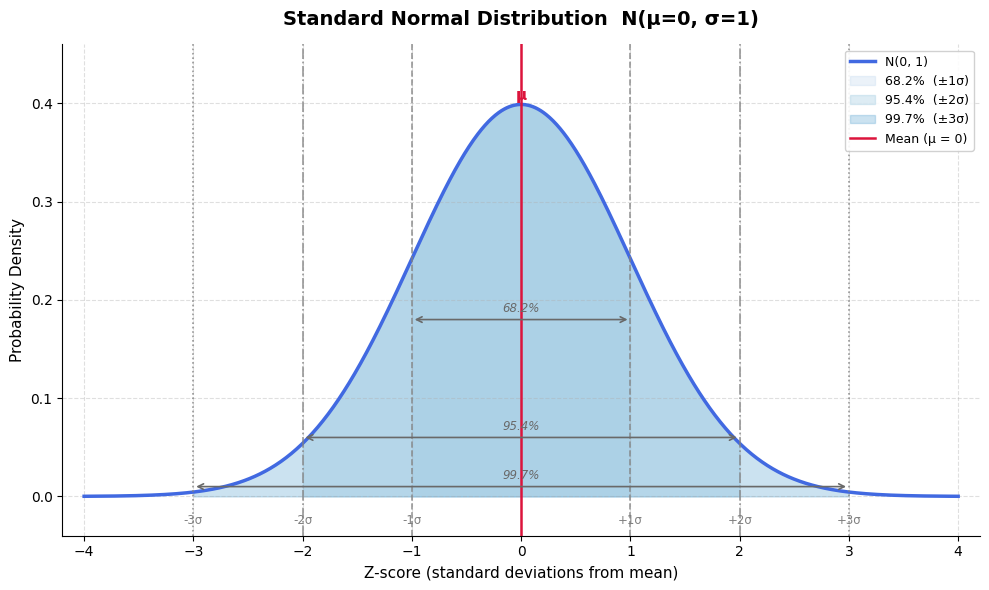

In [52]:
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, loc=0, scale=1)

fig, ax = plt.subplots(figsize=(10, 6))

# --- Main curve ---
ax.plot(x, y, color="royalblue", linewidth=2.5, label="N(0, 1)")

# --- Shaded regions: 1σ, 2σ, 3σ ---
for sigma, color, label in [
    (1, "#c6dbef", "68.2%  (±1σ)"),
    (2, "#9ecae1", "95.4%  (±2σ)"),
    (3, "#6baed6", "99.7%  (±3σ)")
]:
    mask = (x >= -sigma) & (x <= sigma)
    ax.fill_between(x[mask], y[mask], alpha=0.35, color=color, label=label)

# --- Vertical lines at ±1σ, ±2σ, ±3σ ---
for sigma, ls in [(1, "--"), (2, "-."), (3, ":")]:
    for sign in [-1, 1]:
        val = sign * sigma
        ax.axvline(val, color="gray", linestyle=ls, linewidth=1.2, alpha=0.8)
        ax.text(val, -0.018, f"{val:+d}σ", ha="center", va="top",
                fontsize=8.5, color="gray")

# --- Mean line ---
ax.axvline(0, color="crimson", linewidth=1.8, linestyle="-", label="Mean (μ = 0)")
ax.text(0, norm.pdf(0) + 0.005, "μ", ha="center", fontsize=11,
        color="crimson", fontweight="bold")

# --- Percentage annotations inside bands ---
for pct, xpos in [("68.2%", 0), ("95.4%", 0), ("99.7%", 0)]:
    pass  # handled via legend

# --- Bracket-style annotations for σ zones ---
for sigma, pct, ypos in [(1, "68.2%", 0.18), (2, "95.4%", 0.06), (3, "99.7%", 0.01)]:
    ax.annotate(
        "",
        xy=(-sigma, ypos), xytext=(sigma, ypos),
        arrowprops=dict(arrowstyle="<->", color="dimgray", lw=1.2)
    )
    ax.text(0, ypos + 0.008, pct, ha="center", fontsize=8.5,
            color="dimgray", fontstyle="italic")

# --- Formatting ---
ax.set_title("Standard Normal Distribution  N(μ=0, σ=1)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Z-score (standard deviations from mean)", fontsize=11)
ax.set_ylabel("Probability Density", fontsize=11)
ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-0.04, 0.46)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()